# AP 155 Lab Exercise
---
## Exercise 3: Evaluating polynomials (Horner's rule)

_Instructions_: 
- **Report figure (Problem 2):** Create a $2 \times 3$ grid of subplots comparing evaluations of the rational function $r(x)$, see Eq. (4):
    - Columns (3 Methods): Naive method (using direct powers), Horner's method, Rewritten form $s(x)$
    - Rows (2 values of $x$-points) $x= 1.606 + 2^{-52}$ and $2.400 + 2^{-52}i$ where $i\in[0,800]$.

- **Report discussion (Problem 2):** Two questions:
    - Using your figure as reference, compare the rounding error patterns and output stability of Horner's method, naive power evaluation, and rewritten form $s(x)$. Are rounding errors random? Discuss the discrepancies and origin.
    - Explain why algebraically identical expressions (such as Eq. (4) and Eq. (5)) produce different numerical values when implemented in floating-point arithmetic.

  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Ranches, Franc Louis)_: 
- _Student No._: 2024-09153
- _Section_: THR-TX-3

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

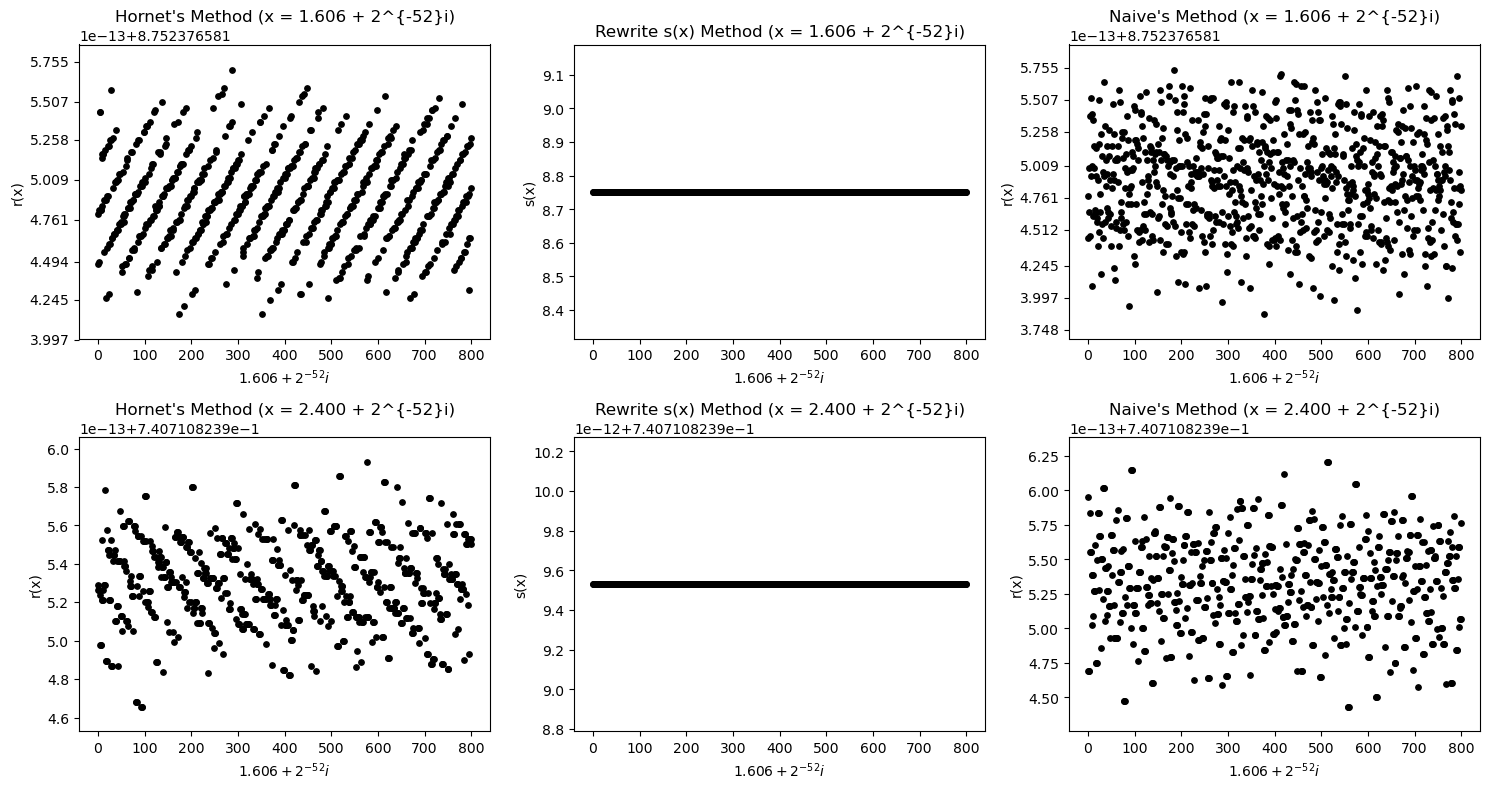

In [1]:
# use `fig, axs = plt.subplots(...)` to generate your figure with subplots
# then call fig to show your image instead of using markdown
# Your goal is to replicate this... feel free to adjust the visuals
import numpy as np
import matplotlib.pyplot as plt

#setting up parameters
i = np.arange(0, 801, dtype=np.float64)
x1 = np.float64(1.606) + np.float64(2)**-52 * i
x2 = np.float64(2.400) + np.float64(2)**-52 * i

num_coeffs = np.array([622, -751, 324, -59, 4], dtype=np.float64)
den_coeffs = np.array([112, -151, 72, -14, 1], dtype=np.float64)

#the hornet's rule function
def eval_hornet(coeffsList, x):
    P = 0
    for n in coeffsList:
        P = P * x + n
    return P

#reversing the list to compensate for the order of powers
rnum_coeffs = num_coeffs[::-1]
rden_coeffs = den_coeffs[::-1]

#evaluating r(x)
eval_1_h = eval_hornet(rnum_coeffs, x1) / eval_hornet(rden_coeffs, x1)
eval_2_h = eval_hornet(rnum_coeffs, x2) / eval_hornet(rden_coeffs, x2)

#function for s(x)
def evalr(x):
    num = 3 * (x - 2) * ((x - 5)**2 + 4)
    den = x + (x - 2)**2 * ((x - 5)**2 + 3)
    return 4 - num / den

eval_1_r = evalr(x1)
eval_2_r = evalr(x2)

#the naive function
def eval_naive(coeffsList, x):
    P = sum([n * (x ** (i)) for i, n in enumerate(coeffsList)])
    return P

#evaluating the r(x)
eval_1_n = eval_naive(num_coeffs, x1) / eval_naive(den_coeffs, x1)
eval_2_n = eval_naive(num_coeffs, x2) / eval_naive(den_coeffs, x2)

#plotting
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].scatter(i, eval_1_h, color='k', s=15)
axes[0, 0].set_xlabel(r'$1.606 + 2^{-52}i$')
axes[0, 0].set_ylabel('r(x)')
axes[0, 0].set_title('Hornet\'s Method (x = 1.606 + 2^{-52}i)')
pad = 0.1 * (eval_1_h.max() - eval_1_h.min())
axes[0, 0].set_ylim(eval_1_h.min() - pad, eval_1_h.max() + pad)

axes[0, 1].scatter(i, eval_1_r, color='k', s=15)
axes[0, 1].set_xlabel(r'$1.606 + 2^{-52}i$')
axes[0, 1].set_ylabel('s(x)')
axes[0, 1].set_title('Rewrite s(x) Method (x = 1.606 + 2^{-52}i)')
pad = 0.1 * (eval_1_r.max() - eval_1_r.min())
axes[0, 1].set_ylim(eval_1_r.min() - pad, eval_1_r.max() + pad)

axes[0, 2].scatter(i, eval_1_n, color='k', s=15)
axes[0, 2].set_xlabel(r'$1.606 + 2^{-52}i$')
axes[0, 2].set_ylabel('r(x)')
axes[0, 2].set_title('Naive\'s Method (x = 1.606 + 2^{-52}i)')
pad = 0.1 * (eval_1_n.max() - eval_1_n.min())
axes[0, 2].set_ylim(eval_1_n.min() - pad, eval_1_n.max() + pad)

axes[1, 0].scatter(i, eval_2_h, color='k', s=15)
axes[1, 0].set_xlabel(r'$1.606 + 2^{-52}i$')
axes[1, 0].set_ylabel('r(x)')
axes[1, 0].set_title('Hornet\'s Method (x = 2.400 + 2^{-52}i)')
pad = 0.1 * (eval_2_h.max() - eval_2_h.min())
axes[1, 0].set_ylim(eval_2_h.min() - pad, eval_2_h.max() + pad)

axes[1, 1].scatter(i, eval_2_r, color='k', s=15)
axes[1, 1].set_xlabel(r'$1.606 + 2^{-52}i$')
axes[1, 1].set_ylabel('s(x)')
axes[1, 1].set_title('Rewrite s(x) Method (x = 2.400 + 2^{-52}i)')
# pad = 0.1 * (eval_2_r.max() - eval_2_r.min())
# axes[1, 1].set_ylim(eval_2_r.min() - pad, eval_2_r.max() + pad)

axes[1, 2].scatter(i, eval_2_n, color='k', s=15)
axes[1, 2].set_xlabel(r'$1.606 + 2^{-52}i$')
axes[1, 2].set_ylabel('r(x)')
axes[1, 2].set_title('Naive\'s Method (x = 2.400 + 2^{-52}i)')
pad = 0.1 * (eval_2_n.max() - eval_2_n.min())
axes[1, 2].set_ylim(eval_2_n.min() - pad, eval_2_n.max() + pad)

plt.tight_layout()
plt.show()
plt.close()

<!--
EDIT ME. Caption of the figure above.
-->

**Figure 1.** Rounding error patterns for three evaluation methods of the rational function $r(x)$ — Horner's method, the rewritten form $s(x)$, and the naive (direct-power) method — near $x_1 = 1.606 + 2^{-52}i$ (top row) and $x_2 = 2.400 + 2^{-52}i$ (bottom row), for $i \in [0, 800]$. Horner's and the naive method show comparable rounding-error magnitude ($\sim10^{-13}$) at both points, while the algebraically rewritten $s(x)$ shows markedly reduced error at $x_1$ (flat, machine-epsilon noise) and a smaller, quantized/staircase error at $x_2$.

### Report discussion

<!--
EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with ~150 words per question.

Using your figure as reference, compare the rounding error patterns and output stability of Horner's method, naive power evaluation, and rewritten form $s(x)$. Are rounding errors random? Discuss the discrepancies and origin.

Explain why algebraically identical expressions (such as Eq. (4) and Eq. (5)) produce different numerical values when implemented in floating-point arithmetic.
-->
(1). No rounding errors are not random, they just appear random because of sensitivity to the last bits of x. The small changes does not average out but gets blown up unpredictably depending on exactly how each intermediate rounding happens to land. And since the 3 methods used have different underlying input "rules"/"form", this is where the patterns and rounding error come from.

(2). This is because in floating-point arithmetic, every arithmetic operation rounds the number to a nearest representable form, and each rounding error propagates, hence giving off different results in the end.

### Other comments

<!--
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.
-->
---

- dahil hindi ko alam paano icopy paste yun plot nag code nalang ulit
- a had help from Claude Sonnet 5 in explaining the concepts and writing the caption

---
## Section 2: Code

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Horner's Rule (Gezerlis Problem 2.11)

**NOTE: Only use 64-bit precision floating-point number data type.**

This problem discusses error buildup when trying to evaluate polynomials without and with the use of *Horner's Rule*. Take a polynomial of degree $n-1$:

$$ P(x) = p_0 + p_1x + p_2x^2 + p_3x^3 + ... + p_{n-1}x^{n-1}. \tag{1} $$

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e. from left to right. Notice that this way of coding up the polynomial contains several (needless) multiplications. This is so because $x^i$ is evaluated as $x\times x\times ... \times x$ (where there are $i-1$ multiplications). Thus, this way of approaching the problem corresponds to
$$ 1 + 2 + ... + n-2 = \frac{(n-1)(n-2)}{2} \tag{2}$$
multiplications, from $x^2$ all the way up to $x^{n-1}$. If we write the polynomial: 
$$ P(x) = p_0 + x(p_1 + x(p_2 + x(p_3 + ... + x(p_{n-2} + xp_{n-1})...))) \tag{3}$$

then we can get away with only $n-1$ multiplications (i.e., no powers are evaluated). This is obviously more efficient, but equally important is the fact that this way we can substantially limit the accumulation of rounding error (especially for polynomials of large degree). Write a function that takes in a list containing the $p_i$'s, say `coeffs`  and the point $x$ and evaluates the value of $P(x)$ in a new way, i.e., from right to left. Apply the previous two functions to the (admittedly artificial) case of:
`coeffs=[(-11)**i for i in reversed(range(8))]` and $x=11.01$. Observe any discrepancy and discuss its origin.

In [3]:
coeffs=[(-11)**i for i in reversed(range(8))]   
x = 11.01

(a) Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e. from left to right... see Eq. (1).

In [4]:
def eval_naive(coeffsList, x):
    """evaluate naively from left to right"""
    # insert your code here
    #This is just Eq. (1) - which pulls the elements of coeffsList and multiply it with x which is raise to the i which is the index of the element
    P = sum([n * (x ** (i)) for i, n in enumerate(coeffsList)])
    return P

print(eval_naive(coeffs, 11.01))

71056.02362162992


(b) Write a function that takes in a list containing the $p_i$'s, say `coeffs`  and the point $x$ and evaluates the value of $P(x)$ in a new way, i.e., from right to left... see Eq. (3).

In [5]:
def eval_horner(coeffsList, x):
    """
        using Horner's rule from right to left
    """
    # insert your code here
    """
        since we need to start from the right we reverse the list then setting a variable P
        to be 0, we start to multiply x then add the next term, this is the same as going through
        the inner brackets firsts 
    """
    P = 0.0
    for n in reversed(coeffsList):
        P = (P * x) + float(n)
    return P

print(eval_horner(coeffs, 11.01))

71056.02362163365


#### Problem 1 code summary
<!--
Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.
-->
---

The first function evaluates polynomials from left to right hence using enumarate to get the elements of the list and to track the index of that element we are able to multiply that element to the varible x with the corresponding power which is the index.

The second function on the other hand uses the Hornet's Rule to evaluate polynomials, which uses  nested brackets as the varible x is factored out. So this time we are going to evaluate from right to left and firstly evaluating the innermost bracket. This is by reversing the list and then multiplying x then adding the next term

### Problem 2: Using the previously-made functions. (Gezerlis Problem 2.12)

**NOTE: Only use 64-bit precision floating-point number data type.**

This problem studies the rational function introduced in the main text, Eq. (2.53) [Gezerlis].

$$ r(x) = \frac{4x^4 - 59x^3 + 324 x^2 - 751x + 622}{x^4 - 14x^3 + 72x^2 - 151x + 112} \tag{4}$$

(a) Apply Horner’s rule twice (once for the numerator and once for the denominator) to produce two plots, one for $x = 1.606 + 2^{−52}i$ and one for $x = 2.400 + 2^{−52}i$ where $i\in[0,800]$ in steps of $1$. Your results should look like Fig. 2.3 in the book (see below). 
![](./figures/gezerlis_fig23.png)

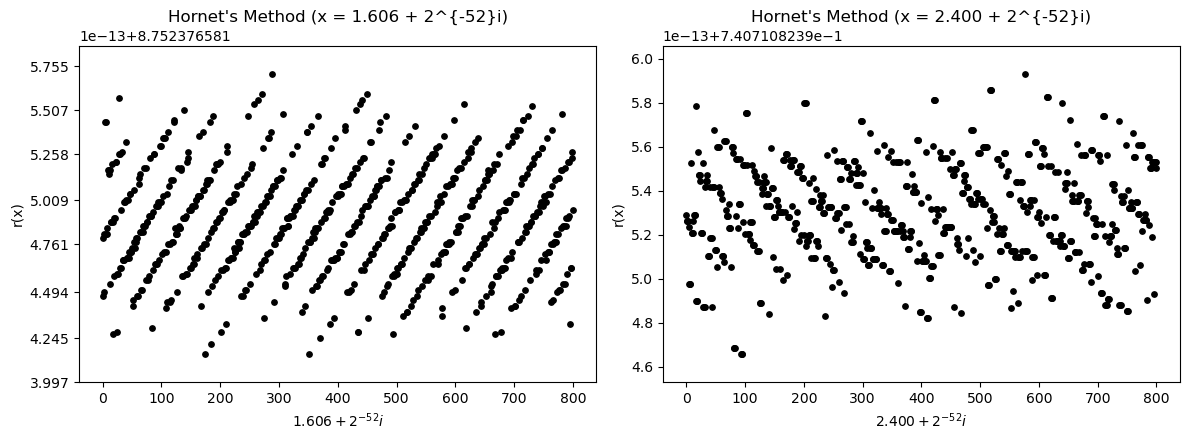

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# take note of the ordering of the coefficients
# note that Eq. (1) is written in increasing powers of x from left to right
# while Eq. (4) is written in decreasing powers of x from left to right

#setting up parameters
i = np.arange(0, 801, dtype=np.float64)
x1 = np.float64(1.606) + np.float64(2)**-52 * i
x2 = np.float64(2.400) + np.float64(2)**-52 * i

num_coeffs = np.array([622, -751, 324, -59, 4], dtype=np.float64)
den_coeffs = np.array([112, -151, 72, -14, 1], dtype=np.float64)

#the hornet's rule function
def eval_hornet(coeffsList, x):
    P = 0
    for n in coeffsList:
        P = P * x + n
    return P

#reversing the list to compensate for the order of powers
rnum_coeffs = num_coeffs[::-1]
rden_coeffs = den_coeffs[::-1]

#evaluating r(x)
eval_1 = eval_hornet(rnum_coeffs, x1) / eval_hornet(rden_coeffs, x1)
eval_2 = eval_hornet(rnum_coeffs, x2) / eval_hornet(rden_coeffs, x2)


# try to learn the syntax in generating subplots as they are very flexible
# plt.subplots()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# you may need to truncate ylim bounds to see the pattern

ax1.scatter(i, eval_1, color='k', s=15)
ax1.set_xlabel(r'$1.606 + 2^{-52}i$')
ax1.set_ylabel('r(x)')
ax1.set_title('Hornet\'s Method (x = 1.606 + 2^{-52}i)')
"""
    since the default plot only shows a line, this rescale the y-axis so we can see the plot
"""
pad1 = 0.1 * (eval_1.max() - eval_1.min()) 
ax1.set_ylim(eval_1.min() - pad1, eval_1.max() + pad1)

ax2.scatter(i, eval_2, color='k', s=15)
ax2.set_xlabel(r'$2.400 + 2^{-52}i$')
ax2.set_ylabel('r(x)')
ax2.set_title('Hornet\'s Method (x = 2.400 + 2^{-52}i)')
"""
    i added this also here just to make sure
"""
pad2 = 0.1 * (eval_2.max() - eval_2.min())
ax2.set_ylim(eval_2.min() - pad2, eval_2.max() + pad2)

plt.tight_layout()
plt.show()
plt.close()


(b) Create a new Python function that codes up the following expression:
$$ s(x)= 4− \frac{3(x−2)[(x−5)^2 + 4]}{x + (x−2)^2[(x−5)^2 + 3]} \tag{5}$$
which is a rewritten version of our rational function. Apply this new function for
the previous two plots and compare the rounding error pattern, size, etc.

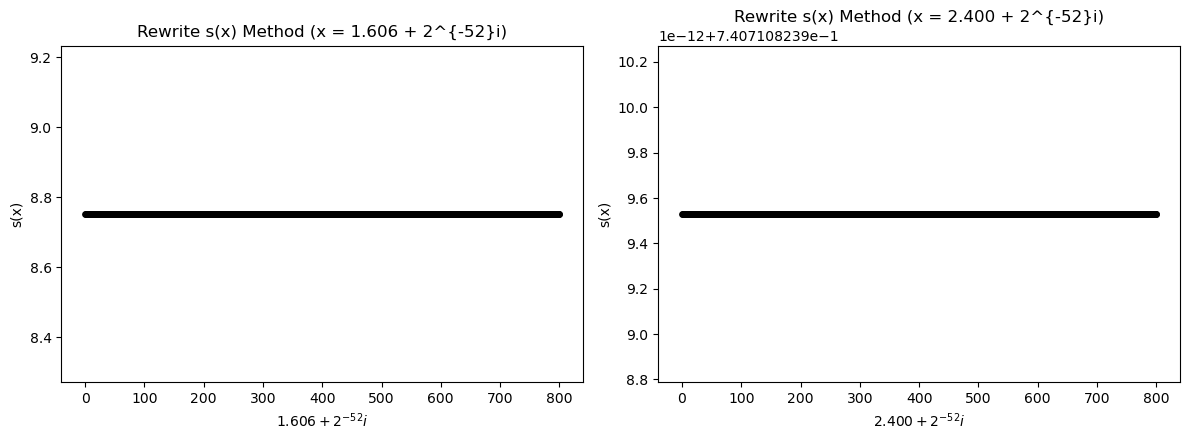

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# take note of the ordering of the coefficients
# note that Eq. (1) is written in increasing powers of x from left to right
# while Eq. (4) is written in decreasing powers of x from left to right

#setting up parameters
i = np.arange(0, 801, dtype=np.float64)
x1 = np.float64(1.606) + np.float64(2)**-52 * i
x2 = np.float64(2.400) + np.float64(2)**-52 * i

# num_coeffs = np.array([622, -751, 324, -59, 4], dtype=np.float64)
# den_coeffs = np.array([112, -151, 72, -14, 1], dtype=np.float64)

#function for s(x)
def evalr(x):
    num = 3 * (x - 2) * ((x - 5)**2 + 4)
    den = x + (x - 2)**2 * ((x - 5)**2 + 3)
    return 4 - num / den

eval_1 = evalr(x1)
eval_2 = evalr(x2)


# try to learn the syntax in generating subplots as they are very flexible
# plt.subplots()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# you may need to truncate ylim bounds to see the pattern

ax1.scatter(i, eval_1, color='k', s=15)
ax1.set_xlabel(r'$1.606 + 2^{-52}i$')
ax1.set_ylabel('s(x)')
ax1.set_title('Rewrite s(x) Method (x = 1.606 + 2^{-52}i)')

ax2.scatter(i, eval_2, color='k', s=15)
ax2.set_xlabel(r'$2.400 + 2^{-52}i$')
ax2.set_ylabel('s(x)')
ax2.set_title('Rewrite s(x) Method (x = 2.400 + 2^{-52}i)')


plt.tight_layout()
plt.show()
plt.close()


(c) Now introduce two more sets of results, this time for the starting expression for $r(x)$ produced using (not Horner’s rule but) the naive implementation, using powers (i.e., the way you would have coded this up before doing problem 2.11).
Interpret your findings.

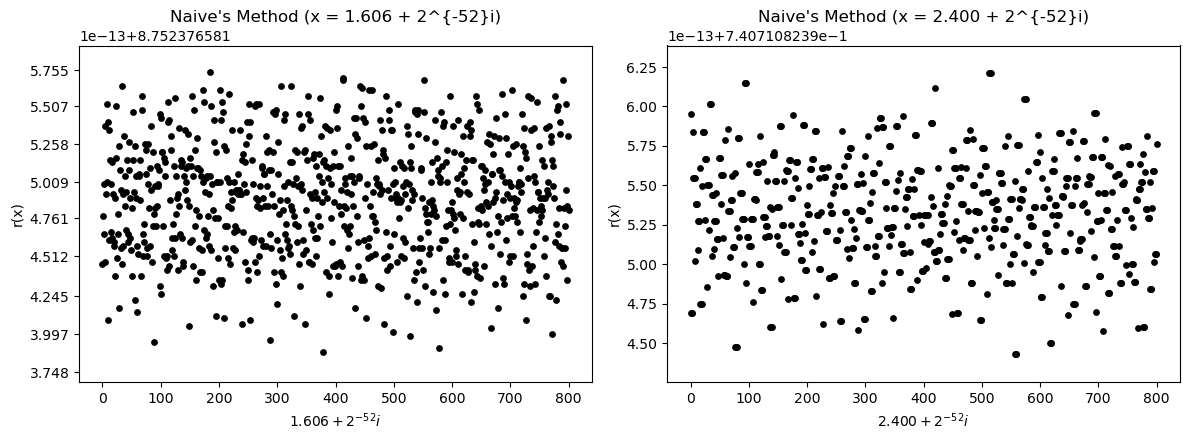

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# take note of the ordering of the coefficients
# note that Eq. (1) is written in increasing powers of x from left to right
# while Eq. (4) is written in decreasing powers of x from left to right

#setting up the parameters 
i = np.arange(0, 801, dtype=np.float64)
x1 = np.float64(1.606) + np.float64(2)**-52 * i
x2 = np.float64(2.400) + np.float64(2)**-52 * i

num_coeffs = np.array([622, -751, 324, -59, 4], dtype=np.float64)
den_coeffs = np.array([112, -151, 72, -14, 1], dtype=np.float64)

#the naive function
def eval_naive(coeffsList, x):
    P = sum([n * (x ** (i)) for i, n in enumerate(coeffsList)])
    return P

#evaluating the r(x)
eval_1 = eval_naive(num_coeffs, x1) / eval_naive(den_coeffs, x1)
eval_2 = eval_naive(num_coeffs, x2) / eval_naive(den_coeffs, x2)


# try to learn the syntax in generating subplots as they are very flexible
# plt.subplots()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# you may need to truncate ylim bounds to see the pattern

ax1.scatter(i, eval_1, color='k', s=15)
ax1.set_xlabel(r'$1.606 + 2^{-52}i$')
ax1.set_ylabel('r(x)')
ax1.set_title('Naive\'s Method (x = 1.606 + 2^{-52}i)')
pad1 = 0.1 * (eval_1.max() - eval_1.min())
ax1.set_ylim(eval_1.min() - pad1, eval_1.max() + pad1)


ax2.scatter(i, eval_2, color='k', s=15)
ax2.set_xlabel(r'$2.400 + 2^{-52}i$')
ax2.set_ylabel('r(x)')
ax2.set_title('Naive\'s Method (x = 2.400 + 2^{-52}i)')
pad2 = 0.1 * (eval_2.max() - eval_2.min())
ax2.set_ylim(eval_2.min() - pad2, eval_2.max() + pad2)

plt.tight_layout()
plt.show()
plt.close()

#### Problem 2 code summary
<!--
Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the scripts and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.
-->
---
(a) The Horner function from Problem 1 was reused, with coefficient lists reversed to match the leading-term-first convention it expects.

(b) $s(x)$ is an algebraically equivalent rewrite of $r(x)$ that avoids the near-cancelling subtraction present in the polynomial form. This reduced the rounding error dramatically from order-1 magnitude noise near $x_2$ down to $\sim10^{-12}$.

(c) The naive (power-based) implementation shows rounding error of the same order of magnitude as Horner's ($\sim10^{-13}$) at both $x_1$ and $x_2$, indicating that the catastrophic cancellation is a property of the coefficient representation itself, not the summation algorithm Horner's usual efficiency/accuracy edge doesn't show up here because it doesn't address the actual source of the error.


---
## Section 3 (Notes)

In [9]:
import numpy as np

# initialize an array with an explicit float64 type
arr = np.array([1.5, 2.73, 3.14], dtype=np.float64)

# cast an existing integer array to float64
int_arr = np.array([1, 2, 3])
float_arr = int_arr.astype(np.float64)

### Representing real numbers

Python employs what are known as double-precision floating point numbers, also called doubles; their storage uses 64 bits in total. Doubles can represent:
$$ \pm 4.9\times10^{-324} \leftrightarrow \pm 1.8\times 10^{308} $$

In [10]:
# we can represent
print(4.9e-324)

# but not 
print(4.9e-325) # this number is too small for our 64bit machine

5e-324
0.0


In [11]:
# we can represent
print(1.8e307)

# but not 
print(1.8e308) # this number is too big for our 64bit machine

1.8e+307
inf


#### Overflow

In [12]:
# exhibits overflow

large = 2.**1021
for i in range(3):
    large *= 2
    print(i, large)

0 4.49423283715579e+307
1 8.98846567431158e+307
2 inf


In [13]:
print(8.98846567431158e+307*1.999999999999999)
print(8.98846567431158e+307*2.)

1.797693134862315e+308
inf


#### Underflow

In [14]:
from math import sqrt

def f(x, nmax=100):
    for i in range(nmax):
        x = sqrt(x)
    for i in range(nmax):
        x = x**2
    return x

for xin in (5., 0.5):
    xout = f(xin)
    print(xin, xout)

5.0 1.0
0.5 0.0


In [15]:
xtilde = 1234567891234567.0
ytilde = 1234567891234566.0

xtilde**2 - ytilde**2 

# this has catastrophic cancellation 
# note you're making the numbers very large (losing precision)
# then subtracting them (propagating lost precision)

2533274790395904.0

In [16]:
# but if you convert into integers first, the result will be exact
# integers have infinite machine precision!

int(xtilde)**2 - int(ytilde)**2 

2469135782469133

In [17]:
# rewritten equivalent and integer
(int(xtilde) - int(ytilde))*(int(xtilde) + int(ytilde)) 

2469135782469133

In [18]:
small = 1/2**50
for i in range(3):
    small /= 2
    print(i, 1 + small, small)

0 1.0000000000000004 4.440892098500626e-16
1 1.0000000000000002 2.220446049250313e-16
2 1.0 1.1102230246251565e-16


In [19]:
print(1. + 2.3e-16)
print(1. + 1.6e-16)
print(1. + 1.12e-16)
print(1. + 1.1e-16)

1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0


In [20]:
0.5e-16+0.5

0.5

In [21]:
xt = 0.1 + 0.2
yt = 0.3
epsilon = 1.e-12
abs(xt-yt) < epsilon

True

In [22]:
xt = 12345678912.345
yt = 12345678912.346
epsilon = 1.e-12
abs(xt-yt) < epsilon

def findmax(x,y):
    return max(abs(x),abs(y))

abs(xt-yt)/findmax(xt,yt) < epsilon

True

In [23]:
# floating pt arithmetic is not associative

print((0.7 + 0.1) + 0.3)
print(0.7 + (0.1 + 0.3))

x=1e20
y=-1e20
z=1.0

print((x+y) + z)
print(x + (y+z))

1.0999999999999999
1.1
1.0
0.0


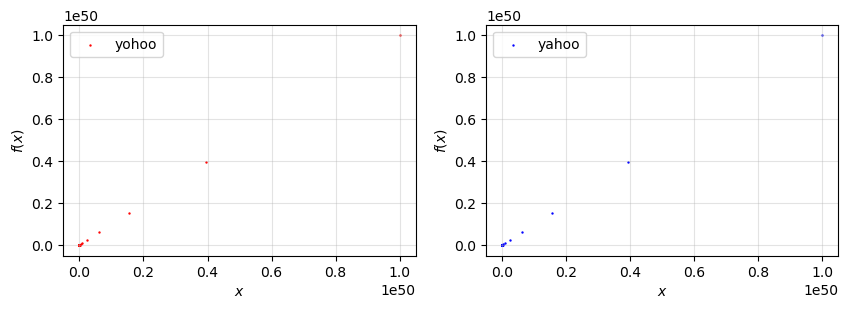

In [24]:
xlist = np.logspace(10, 50, 100)
ylist = xlist
ylist2 = xlist**2

fig, axs = plt.subplots(1,2, figsize=(10,3))
axs[0].scatter(xlist, ylist, s=0.5, c='r', label='yohoo')
axs[1].scatter(xlist, ylist, s=0.5, c='b', label='yahoo')
for ax in axs:
    ax.grid(True, alpha=0.35)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$f(x)$')
    ax.legend()
plt.show()